# Limpieza, Reetiquetado y Correlacion de Riesgos Sismicos, Fracturas e Inundaciones

**Objetivo**: Hacer una limpieza profunda de los datos, reetiquetar variables de forma consistente, y analizar si las zonas con mas sismo y fracturas tienen mayor tendencia a inundaciones en CDMX.

Este cuaderno combina auditoria de calidad, limpieza agresiva, normalizacion de categorias, y analisis de correlacion bivariado con cruces espaciales.

In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import warnings

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette("husl")

## 1. Carga y Auditoria Inicial de Datos

In [ ]:
# Cargar la version limpia v2
print("Cargando datos...")
ageb_clean = gpd.read_file('output/zonas_ageb_clean_v2.json')

print("Datos cargados.\n")

# Funcion de auditoria
def auditar_dataset(df, nombre):
    print(f"\n{'='*70}")
    print(f" AUDITORIA: {nombre}")
    print(f"{'='*70}")
    print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
    print(f"\nTipos de datos:\n{df.dtypes.value_counts()}")
    print(f"\nPorcentaje de nulos por columna:")
    nulos = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    print(nulos[nulos > 0].head(10))
    print(f"\nDuplicados totales: {df.duplicated().sum()}")
    print(f"\nPrimeras 3 filas:")
    display(df.head(3))

# Auditar dataset v2
auditar_dataset(ageb_clean, "AGEB Clean v2")

Cargando datos...
Datos cargados.


 AUDITORIA: AGEB Clean
Dimensiones: 1,018 filas x 16 columnas

Tipos de datos:
str         6
int32       5
float64     4
geometry    1
Name: count, dtype: int64

Porcentaje de nulos por columna:
Series([], dtype: float64)

Duplicados totales: 0

Primeras 3 filas:


,CVEGEO,CVE_ENT,CVE_MUN,CVE_LOC,CVE_AGEB,tipo_suelo,area_total,riesgo_sismo,riesgo_inundacion,pct_afectacion_inundacion,suma_riesgos,riesgo_general,area_total_norm,pct_afectacion_inundacion_norm,tipo_suelo_label,geometry
0,0900700011034,09,007,0001,1034,3,6.681231e+08,5,5,0.051608,10,5,0.337955,0.534989,Arenoso,"POLYGON ((-99.0568 19.36313, -99.0576 19.35951..."
1,0900700013721,09,007,0001,3721,3,6.681231e+08,5,5,0.033589,10,5,0.337955,0.344787,Arenoso,"POLYGON ((-99.06016 19.36342, -99.06042 19.362..."
2,0900700013647,09,007,0001,3647,3,6.681231e+08,5,5,0.017394,10,5,0.337955,0.173842,Arenoso,"POLYGON ((-99.11409 19.37398, -99.11326 19.373..."



 AUDITORIA: RUSE (Siniestros)
Dimensiones: 31,589 filas x 23 columnas

Tipos de datos:
str        17
int64       4
float64     2
Name: count, dtype: int64

Porcentaje de nulos por columna:
hora          0.949698
seguimie      0.110798
causas        0.066479
atendio_dg    0.056982
colonia       0.009497
fuente        0.009497
atendio       0.009497
taxonomia     0.003166
dtype: float64

Duplicados totales: 0

Primeras 3 filas:


,id,geo_point_2d,geo_shape,folio,fecha,hora,fenomeno,taxonomia,grupo,incidente,...,alcaldia,atendio,atendio_dg,fuente,atencion,seguimie,lesionados,fallecidos,latitud,longitud
0,10001,"19.31089531,-99.05992219","{""type"": ""Point"", ""coordinates"": [-99.05992219...",391,25/01/2019,21:30:00,QUIMICO-TECNOLOGICO,INCENDIO URBANO,NO APLICA,INCENDIO DE PASTO EN BALDIO O CAMELLON,...,IZTAPALAPA,"HCB, SSC","REGIONAL ORIENTE, S.-13 Y S.-30 (TIEMPO DE RES...",SSC,"EN EL PANTEON “SAN LORENZO TEZONCO”, SE SUSCIT...",NO APLICA,0,0,19.310895,-99.059922
1,10002,"19.30106176,-99.17409218","{""type"": ""Point"", ""coordinates"": [-99.17409217...",392,25/01/2019,23:35:00,QUIMICO-TECNOLOGICO,DERRAME O FUGA DE SUSTANCIA PELIGROSA,NO APLICA,FUGA DE GAS NATURAL EN TOMAS DOMICILIARIAS,...,TLALPAN,"HCB, SAC, GAS NATUTGY",NO RELEVANTE,FRECUENCIA DE RADIO,SE SUSCITO FUGA DE GAS NATURAL EN TUBERIA DE A...,NO APLICA,0,0,19.301062,-99.174092
2,10008,"19.33917957,-99.31114328","{""type"": ""Point"", ""coordinates"": [-99.31114327...",398,26/01/2019,12:38:00,SOCIORGANIZATIVO,ACCIDENTES TERRESTRES,NO APLICA,ACCIDENTES EN TRANSPORTE DE CARGA,...,CUAJIMALPA DE MORELOS,POLICIA FEDERAL,NO RELEVANTE,FRECUENCIA DE RADIO,SE TUVO CONOCIMIENTO DE LA VOLCADURA DE UN CAM...,NO APLICA,1,0,19.339180,-99.311143



 AUDITORIA: IMU 2020
Dimensiones: 50,790 filas x 26 columnas

Tipos de datos:
float64    15
str         7
int64       4
Name: count, dtype: int64

Porcentaje de nulos por columna:
fn_AGEB        9.21835
fn_CVE_AGEB    9.21835
dtype: float64

Duplicados totales: 0

Primeras 3 filas:


...

,id,geo_point_2d,geo_shape,fenomeno,taxonomia,r_p_v_e,intensidad,descripcio,fuente,cvegeo,alcaldia,entidad,area_m2,perime_m,period_ret,intens_uni,intens_num,int2
0,35.0,"19.2422518066,-99.0731823535","{""type"": ""Polygon"", ""coordinates"": [[[-99.0760...",Hidrometeorológicos,Inundaciones,Peligro,Bajo,Análisis del índice de Inundabilidad de la CON...,"Dirección de Análisis de Riesgo de la SPCGIR, ...",0901300011154,Xochimilco,Ciudad de México,973904.029201,6805.448256,5 años,% de area inundable,26 a 49,2
1,56.0,"19.2236128042,-99.1083418839","{""type"": ""Polygon"", ""coordinates"": [[[-99.1064...",Hidrometeorológicos,Inundaciones,Peligro,Muy Bajo,Análisis del índice de Inundabilidad de la CON...,"Dirección de Análisis de Riesgo de la SPCGIR, ...",0901300010601,Xochimilco,Ciudad de México,795548.364401,4693.752691,5 años,% de area inundable,0 a 25,1
2,32.0,"19.3809650541,-99.1373113251","{""type"": ""Polygon"", ""coordinates"": [[[-99.1366...",Hidrometeorológicos,Inundaciones,Peligro,Muy Alto,Análisis del índice de Inundabilidad de la CON...,"Dirección de Análisis de Riesgo de la SPCGIR, ...",0901400010524,Benito Juárez,Ciudad de México,168263.324089,1712.409605,5 años,% de area inundable,100,5



 AUDITORIA: Susceptibilidad Laderas
Dimensiones: 4,908 filas x 15 columnas

Tipos de datos:
str        11
float64     3
int64       1
Name: count, dtype: int64

Porcentaje de nulos por columna:
Series([], dtype: float64)

Duplicados totales: 0

Primeras 3 filas:


,id,geo_point_2d,geo_shape,fenomeno,taxonomia,r_p_v_e,intensidad,descripcio,fuente,cvegeo,alcaldia,entidad,area_m2,perime_m,int2
0,1159.0,"19.2350242034,-99.1254599283","{""type"": ""Polygon"", ""coordinates"": [[[-99.1240...",Geológicos,Susceptibilidad por laderas,Peligro,Muy Bajo,Zonas susceptibles a peligro por Procesos de R...,"Dirección de Análisis de Riesgo de la SPCGIR, ...",0901300010599,Xochimilco,Ciudad de México,6.438690e+05,3650.262474,1
1,868.0,"19.3158892275,-99.0867548378","{""type"": ""MultiPolygon"", ""coordinates"": [[[[-9...",Geológicos,Susceptibilidad por laderas,Peligro,Muy Bajo,Zonas susceptibles a peligro por Procesos de R...,"Dirección de Análisis de Riesgo de la SPCGIR, ...",0900700014467,Iztapalapa,Ciudad de México,7.515951e+04,1214.630190,1
2,884.0,"19.2248189956,-99.2187732907","{""type"": ""MultiPolygon"", ""coordinates"": [[[[-9...",Geológicos,Susceptibilidad por laderas,Peligro,Bajo,Zonas susceptibles a peligro por Procesos de R...,"Dirección de Análisis de Riesgo de la SPCGIR, ...",0901200262297,Tlalpan,Ciudad de México,2.324595e+06,6710.755823,2



 AUDITORIA: Fracturas
Dimensiones: 6,965 filas x 12 columnas

Tipos de datos:
str         9
int64       1
float64     1
geometry    1
Name: count, dtype: int64

Porcentaje de nulos por columna:
Series([], dtype: float64)

Duplicados totales: 0

Primeras 3 filas:


,Id,TAXONOMIA,FENOMENO,R_P_V_E,INTENSIDAD,DESCRIPCIO,FUENTE,CVE_ENT,NOM_ENT,MAGNI_UNI,MAGNI_NUM,geometry
0,1,Geológico,Fractura,N/A,N/A,CARTOGRAFIA_CAMPO_ESCANDON,"SPC-IPN, 2016",15,Cuauhtémoc,Metros,27.76080,"LINESTRING (-99.18352 19.40741, -99.18341 19.4..."
1,2,Geológico,Fractura,N/A,N/A,CARTOGRAFIA_CAMPO_ESCANDON,"SPC-IPN, 2016",16,Miguel Hidalgo,Metros,7.58411,"LINESTRING (-99.18405 19.40742, -99.18398 19.4..."
2,3,Geológico,Fractura,N/A,N/A,CARTOGRAFIA_CAMPO_ESCANDON,"SPC-IPN, 2016",16,Miguel Hidalgo,Metros,10.24420,"LINESTRING (-99.18412 19.40704, -99.18403 19.4..."


## 2. Limpieza Profunda y Estandarizacion

In [11]:
def limpiar_dataset(df, nombre):
    """Limpieza agresiva: elimina duplicados, valores nulos extremos, tipos incorrectos."""
    df_limpio = df.copy()
    
    # Eliminar duplicados
    dup_antes = len(df_limpio)
    df_limpio = df_limpio.drop_duplicates()
    print(f"OK {nombre}: Eliminados {dup_antes - len(df_limpio)} duplicados")
    
    # Convertir columnas numericas
    for col in df_limpio.columns:
        if col.lower() not in ['geometry', 'geom']:
            try:
                df_limpio[col] = pd.to_numeric(df_limpio[col], errors='ignore')
            except:
                pass
    
    # Eliminar filas completamente vacias
    df_limpio = df_limpio.dropna(how='all')
    
    # Para columnas numericas, eliminar outliers extremos (metodo IQR agresivo)
    numeric_cols = df_limpio.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        Q1 = df_limpio[col].quantile(0.01)  # 1er percentil
        Q3 = df_limpio[col].quantile(0.99)  # 99o percentil
        IQR = Q3 - Q1
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR
        
        outliers = ((df_limpio[col] < lower_bound) | (df_limpio[col] > upper_bound)).sum()
        if outliers > 0:
            df_limpio = df_limpio[(df_limpio[col] >= lower_bound) & (df_limpio[col] <= upper_bound)]
            print(f"  OK {col}: Eliminados {outliers} outliers extremos")
    
    return df_limpio

def limpiar_fracturas(gdf, nombre):
    """Limpieza ligera para la capa de fracturas: elimina duplicados y alinea CRS."""
    gdf_limpio = gdf.copy().drop_duplicates()
    if getattr(gdf_limpio, 'crs', None) is None:
        gdf_limpio = gdf_limpio.set_crs(ageb_clean.crs if ageb_clean.crs is not None else 'EPSG:4326')
    elif ageb_clean.crs is not None and gdf_limpio.crs != ageb_clean.crs:
        gdf_limpio = gdf_limpio.to_crs(ageb_clean.crs)
    gdf_limpio = gdf_limpio[gdf_limpio.geometry.notna()].copy()
    print(f"OK {nombre}: {len(gdf_limpio)} geometrías válidas")
    return gdf_limpio

# Limpiar datasets principales
print("\nLIMPIEZA AGRESIVA:\n")
sismo_clean = limpiar_dataset(sismo, "Sismo")
inundacion_clean = limpiar_dataset(inundacion, "Inundacion")
laderas_clean = limpiar_dataset(laderas, "Laderas")
ruse_clean = limpiar_dataset(ruse, "RUSE")
imu_clean = limpiar_dataset(imu, "IMU")
fracturas_clean = limpiar_fracturas(fracturas, "Fracturas")

print("\nLimpieza completada.\n")


LIMPIEZA AGRESIVA:

OK Sismo: Eliminados 0 duplicados
  OK area_m2: Eliminados 30 outliers extremos
OK Inundacion: Eliminados 0 duplicados
  OK area_m2: Eliminados 30 outliers extremos
OK Laderas: Eliminados 0 duplicados
  OK area_m2: Eliminados 30 outliers extremos
OK RUSE: Eliminados 0 duplicados
  OK lesionados: Eliminados 28 outliers extremos
  OK fallecidos: Eliminados 6 outliers extremos
  OK latitud: Eliminados 12 outliers extremos
OK IMU: Eliminados 0 duplicados
  OK LOC: Eliminados 24 outliers extremos
  OK OVSDE: Eliminados 15 outliers extremos
  OK OVSEE: Eliminados 76 outliers extremos
OK Fracturas: 6965 geometrías válidas

Limpieza completada.



## 3. Reetiquetado de Variables y Categorias de Riesgo

In [17]:
# Funcion para categorizar riesgo de forma homogenea
def categorizar_riesgo(valor):
    """Convierte intensidades textuales o numericas a categorias estandarizadas de riesgo."""
    if pd.isna(valor):
        return 'SIN_DATO'
    try:
        v = float(valor)
        if v <= 1:
            return 'BAJO'
        elif v == 2:
            return 'MEDIO'
        elif v == 3:
            return 'ALTO'
        else:
            return 'MUY_ALTO'
    except:
        s = str(valor).lower().strip()
        if any(x in s for x in ['muy bajo', 'muy_bajo', 'low']):
            return 'BAJO'
        elif any(x in s for x in ['bajo', 'medium low', 'media baja']):
            return 'BAJO'
        elif any(x in s for x in ['medio', 'medium', 'media']):
            return 'MEDIO'
        elif any(x in s for x in ['alto', 'high', 'alta']):
            return 'ALTO'
        elif any(x in s for x in ['muy alto', 'very high', 'extremo']):
            return 'MUY_ALTO'
        else:
            return 'SIN_CLASIFICAR'

print("REETIQUETADO DE VARIABLES:\n")

# Sismo: usar intensidad textual e indice numerico int2
sismo_clean['SISMO_CATEGORIA_RIESGO'] = sismo_clean['intensidad'].apply(categorizar_riesgo)
sismo_clean['SISMO_INT2_PUNTAJE'] = pd.to_numeric(sismo_clean['int2'], errors='coerce').fillna(0)
sismo_clean['SISMO_ALTO_RIESGO'] = sismo_clean['SISMO_CATEGORIA_RIESGO'].isin(['ALTO', 'MUY_ALTO']).astype(int)

# Inundacion: usar intensidad textual e indice numerico int2
inundacion_clean['INUNDACION_CATEGORIA_RIESGO'] = inundacion_clean['intensidad'].apply(categorizar_riesgo)
inundacion_clean['INUNDACION_INT2_PUNTAJE'] = pd.to_numeric(inundacion_clean['int2'], errors='coerce').fillna(0)
inundacion_clean['INUNDACION_ALTO_RIESGO'] = inundacion_clean['INUNDACION_CATEGORIA_RIESGO'].isin(['ALTO', 'MUY_ALTO']).astype(int)

print("OK Sismo: Categorias creadas")
print("OK Inundacion: Categorias creadas")
print("OK Variables binarias de alto riesgo creadas")
print("\nReetiquetado completado.\n")

REETIQUETADO DE VARIABLES:

OK Sismo: Categorias creadas
OK Inundacion: Categorias creadas
OK Variables binarias de alto riesgo creadas

Reetiquetado completado.



## 4. Unificacion de Zonas de Sismo, Fracturas e Inundaciones

In [18]:
# Crear matriz unificada a nivel de zonas del atlas de riesgo
print("UNIFICACION DE DATOS A NIVEL DE ZONAS, SISMOS, FRACTURAS E INUNDACIONES:\n")

import json
from shapely.geometry import shape

def preparar_geodf(df, nombre):
    base = df.copy()
    if 'geo_shape' not in base.columns:
        raise ValueError(f'El dataset {nombre} no tiene columna geo_shape')
    base['geometry'] = base['geo_shape'].apply(lambda x: shape(json.loads(x)) if pd.notna(x) else None)
    gdf = gpd.GeoDataFrame(base, geometry='geometry', crs='EPSG:4326')
    gdf = gdf[gdf.geometry.notna()].copy()
    print(f"OK {nombre}: {len(gdf)} geometrías válidas")
    return gdf

sismo_geo = preparar_geodf(sismo_clean, 'Sismo')
inundacion_geo = preparar_geodf(inundacion_clean, 'Inundacion')

if 'id' not in sismo_geo.columns or 'id' not in inundacion_geo.columns:
    raise KeyError('Los atlas de sismo e inundacion deben conservar la columna id')

# Agregacion de sismo a nivel de zona del atlas
sismo_ageb = sismo_geo.groupby('id', as_index=False).agg(
    sismo_intensidad_promedio=('SISMO_INT2_PUNTAJE', 'mean'),
    sismo_count_alto_riesgo=('SISMO_ALTO_RIESGO', 'sum'),
    sismo_pct_alto_riesgo=('SISMO_ALTO_RIESGO', 'mean'),
    sismo_tiene_alto_riesgo=('SISMO_ALTO_RIESGO', 'max')
)
sismo_ageb['sismo_tiene_alto_riesgo'] = (sismo_ageb['sismo_tiene_alto_riesgo'] > 0).astype(int)

# Agregacion de inundacion a nivel de zona del atlas
inundacion_ageb = inundacion_geo.groupby('id', as_index=False).agg(
    inundacion_intensidad_promedio=('INUNDACION_INT2_PUNTAJE', 'mean'),
    inundacion_count_alto_riesgo=('INUNDACION_ALTO_RIESGO', 'sum'),
    inundacion_pct_alto_riesgo=('INUNDACION_ALTO_RIESGO', 'mean'),
    inundacion_tiene_alto_riesgo=('INUNDACION_ALTO_RIESGO', 'max')
)
inundacion_ageb['inundacion_tiene_alto_riesgo'] = (inundacion_ageb['inundacion_tiene_alto_riesgo'] > 0).astype(int)

# Fracturas por interseccion espacial con zonas sismicas
try:
    fracturas_en_sismo = gpd.sjoin(
        sismo_geo[['id', 'geometry']].copy(),
        fracturas_clean[['geometry']].copy(),
        how='left',
        predicate='intersects'
    )
    fracturas_ageb = fracturas_en_sismo.groupby('id').agg(fracturas_count=('index_right', 'count')).reset_index()
    fracturas_ageb['fracturas_tiene_alto_riesgo'] = (fracturas_ageb['fracturas_count'] > 0).astype(int)
    print(f"OK Fracturas agregadas: {len(fracturas_ageb)} zonas con interseccion")
except Exception as e:
    print(f"Advertencia: No se pudo calcular la interseccion espacial de fracturas: {str(e)}")
    fracturas_ageb = pd.DataFrame(columns=['id', 'fracturas_count', 'fracturas_tiene_alto_riesgo'])

print(f"OK Sismo agregado: {len(sismo_ageb)} zonas")
print(f"OK Inundacion agregada: {len(inundacion_ageb)} zonas")

# Merge de riesgos y fracturas
ageb_riesgos = sismo_ageb.merge(inundacion_ageb, on='id', how='outer')
ageb_riesgos = ageb_riesgos.merge(fracturas_ageb, on='id', how='left')

# Completar nulos y crear variables derivadas
for col in ['sismo_tiene_alto_riesgo', 'inundacion_tiene_alto_riesgo', 'fracturas_tiene_alto_riesgo']:
    if col in ageb_riesgos.columns:
        ageb_riesgos[col] = ageb_riesgos[col].fillna(0)
for col in ['sismo_intensidad_promedio', 'sismo_count_alto_riesgo', 'sismo_pct_alto_riesgo', 'inundacion_intensidad_promedio', 'inundacion_count_alto_riesgo', 'inundacion_pct_alto_riesgo', 'fracturas_count']:
    if col in ageb_riesgos.columns:
        ageb_riesgos[col] = ageb_riesgos[col].fillna(0)

def normalizar_serie(serie):
    minimo = serie.min()
    maximo = serie.max()
    if pd.isna(minimo) or pd.isna(maximo) or maximo == minimo:
        return pd.Series(0, index=serie.index)
    return (serie - minimo) / (maximo - minimo)

ageb_riesgos['sismo_norm'] = normalizar_serie(ageb_riesgos['sismo_intensidad_promedio'])
ageb_riesgos['fracturas_norm'] = normalizar_serie(ageb_riesgos['fracturas_count'])
ageb_riesgos['indice_exposicion_sismo_fracturas'] = ageb_riesgos['sismo_norm'] + ageb_riesgos['fracturas_norm']

q1, q2, q3 = ageb_riesgos['indice_exposicion_sismo_fracturas'].quantile([0.25, 0.50, 0.75]).tolist()

def categorizar_exposicion(score):
    if pd.isna(score):
        return 'SIN_DATO'
    if score <= q1:
        return 'BAJO'
    elif score <= q2:
        return 'MEDIO'
    elif score <= q3:
        return 'ALTO'
    else:
        return 'MUY_ALTO'

ageb_riesgos['exposicion_sismo_fracturas_categoria'] = ageb_riesgos['indice_exposicion_sismo_fracturas'].apply(categorizar_exposicion)
ageb_riesgos['riesgo_sismo_o_inundacion'] = np.maximum(ageb_riesgos['sismo_tiene_alto_riesgo'], ageb_riesgos['inundacion_tiene_alto_riesgo'])
ageb_riesgos['riesgo_sismo_y_fracturas'] = ((ageb_riesgos['sismo_tiene_alto_riesgo'] > 0) & (ageb_riesgos['fracturas_tiene_alto_riesgo'] > 0)).astype(int)

print("\nOK Variables combinadas creadas:")
print(f"  - Zonas con sismo y fracturas: {int(ageb_riesgos['riesgo_sismo_y_fracturas'].sum())}")
print(f"  - Zonas con sismo o inundacion: {int(ageb_riesgos['riesgo_sismo_o_inundacion'].sum())}")
print(f"\nUnificacion completada.\n")

UNIFICACION DE DATOS A NIVEL DE ZONAS, SISMOS, FRACTURAS E INUNDACIONES:

OK Sismo: 4878 geometrías válidas
OK Inundacion: 4878 geometrías válidas
OK Fracturas agregadas: 2439 zonas con interseccion
OK Sismo agregado: 2439 zonas
OK Inundacion agregada: 2439 zonas

OK Variables combinadas creadas:
  - Zonas con sismo y fracturas: 380
  - Zonas con sismo o inundacion: 1616

Unificacion completada.



## 5. Correlacion entre Sismo, Fracturas e Inundacion

ANALISIS DE CORRELACION:

Correlaciones puntuales:
Sismo vs Inundacion:
  Pearson: 0.8473 (p=0.000000)
  Spearman: 0.8473 (p=0.000000)
Fracturas vs Inundacion:
  Pearson: 0.0636 (p=0.001664)
  Spearman: 0.0279 (p=0.168812)
Sismo + Fracturas vs Inundacion:
  Pearson: 0.7926 (p=0.000000)
  Spearman: 0.7523 (p=0.000000)

Tabla comparativa de tendencia a inundacion por grupo:


,count,mean,median
grupo_exposicion,,,
Sismo alto + Fracturas altas,1487,0.967720,1.0
Sismo bajo + Fracturas altas,952,0.135504,0.0


Tabla de contingencia: Sismo alto + Fracturas altas vs Inundacion alta
inundacion_alta    0     1   All
row_0                           
0                823   129   952
1                 48  1439  1487
All              871  1568  2439



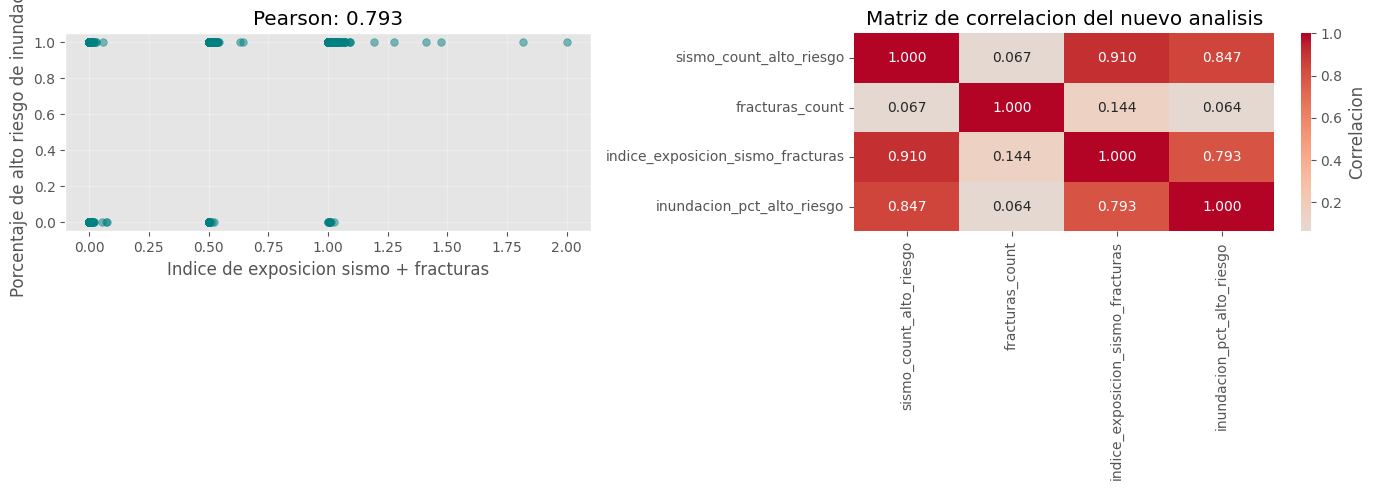

Analisis de correlacion completado.



In [19]:
print("ANALISIS DE CORRELACION:\n")

# Correlacion entre exposicion sismica, fracturas e inundacion
cols_corr = ['sismo_count_alto_riesgo', 'fracturas_count', 'indice_exposicion_sismo_fracturas', 'inundacion_pct_alto_riesgo']
df_corr = ageb_riesgos[cols_corr].dropna()

def reportar_correlacion(x_col, y_col, etiqueta):
    sub = ageb_riesgos[[x_col, y_col]].dropna()
    if len(sub) < 3 or sub[x_col].std() == 0 or sub[y_col].std() == 0:
        print(f"{etiqueta}: no calculable por falta de variacion")
        return np.nan, np.nan, sub
    pearson_val, pearson_p = pearsonr(sub[x_col], sub[y_col])
    spearman_val, spearman_p = spearmanr(sub[x_col], sub[y_col])
    print(f"{etiqueta}:")
    print(f"  Pearson: {pearson_val:.4f} (p={pearson_p:.6f})")
    print(f"  Spearman: {spearman_val:.4f} (p={spearman_p:.6f})")
    return pearson_val, pearson_p, sub

print("Correlaciones puntuales:")
pearson_sismo_inund, _, _ = reportar_correlacion('sismo_count_alto_riesgo', 'inundacion_pct_alto_riesgo', 'Sismo vs Inundacion')
pearson_fract_inund, _, _ = reportar_correlacion('fracturas_count', 'inundacion_pct_alto_riesgo', 'Fracturas vs Inundacion')
pearson_combo_inund, _, df_combo = reportar_correlacion('indice_exposicion_sismo_fracturas', 'inundacion_pct_alto_riesgo', 'Sismo + Fracturas vs Inundacion')
print()

# Grupos de exposicion para comparar tendencia a inundacion
sismo_umbral = ageb_riesgos['sismo_count_alto_riesgo'].median()
fracturas_umbral = ageb_riesgos['fracturas_count'].median()
inundacion_umbral = ageb_riesgos['inundacion_pct_alto_riesgo'].median()
ageb_riesgos['sismo_alto'] = (ageb_riesgos['sismo_count_alto_riesgo'] >= sismo_umbral).astype(int)
ageb_riesgos['fracturas_altas'] = (ageb_riesgos['fracturas_count'] >= fracturas_umbral).astype(int)
ageb_riesgos['inundacion_alta'] = (ageb_riesgos['inundacion_pct_alto_riesgo'] >= inundacion_umbral).astype(int)
ageb_riesgos['grupo_exposicion'] = np.select(
    [
        (ageb_riesgos['sismo_alto'] == 1) & (ageb_riesgos['fracturas_altas'] == 1),
        (ageb_riesgos['sismo_alto'] == 1) & (ageb_riesgos['fracturas_altas'] == 0),
        (ageb_riesgos['sismo_alto'] == 0) & (ageb_riesgos['fracturas_altas'] == 1)
    ],
    [
        'Sismo alto + Fracturas altas',
        'Sismo alto + Fracturas bajas',
        'Sismo bajo + Fracturas altas'
    ],
    default='Sismo bajo + Fracturas bajas'
)

resumen_grupos = ageb_riesgos.groupby('grupo_exposicion')['inundacion_pct_alto_riesgo'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False)
print("Tabla comparativa de tendencia a inundacion por grupo:")
display(resumen_grupos)

contingencia = pd.crosstab(ageb_riesgos['sismo_alto'] & ageb_riesgos['fracturas_altas'], ageb_riesgos['inundacion_alta'], margins=True)
print("Tabla de contingencia: Sismo alto + Fracturas altas vs Inundacion alta")
print(contingencia)
print()

# Matriz de correlacion visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if not np.isnan(pearson_combo_inund):
    axes[0].scatter(df_combo['indice_exposicion_sismo_fracturas'], df_combo['inundacion_pct_alto_riesgo'], alpha=0.5, s=30, color='teal')
    axes[0].set_xlabel('Indice de exposicion sismo + fracturas')
    axes[0].set_ylabel('Porcentaje de alto riesgo de inundacion')
    axes[0].set_title(f'Pearson: {pearson_combo_inund:.3f}')
else:
    axes[0].text(0.5, 0.5, 'Datos sin variacion suficiente\npara correlacion', ha='center', va='center')
    axes[0].set_title('Relacion sismo + fracturas vs inundacion')
axes[0].grid(True, alpha=0.3)

corr_matrix = ageb_riesgos[['sismo_count_alto_riesgo', 'fracturas_count', 'indice_exposicion_sismo_fracturas', 'inundacion_pct_alto_riesgo']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=axes[1], cbar_kws={'label': 'Correlacion'})
axes[1].set_title('Matriz de correlacion del nuevo analisis')

plt.tight_layout()
plt.show()

print("Analisis de correlacion completado.\n")

## 6. Visualizacion de Sismo, Fracturas e Inundacion

VISUALIZACION DE RIESGOS:



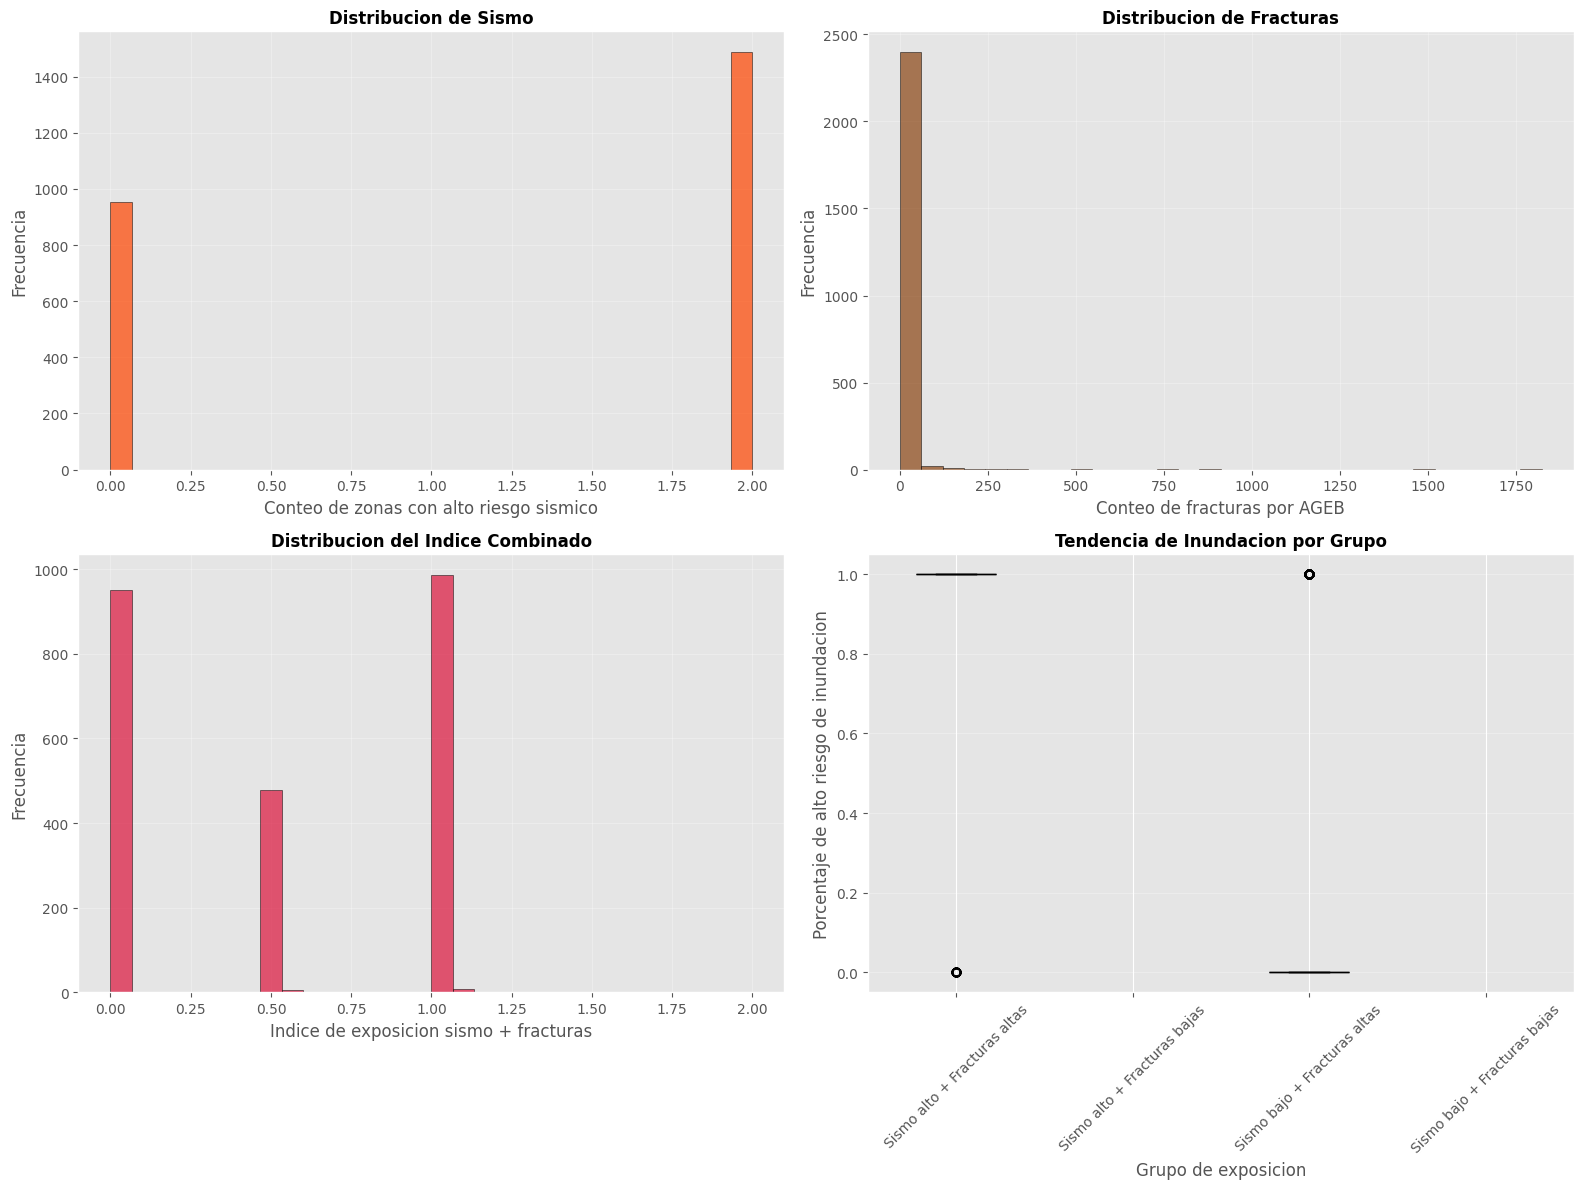

Visualizacion completada.



In [21]:
print("VISUALIZACION DE RIESGOS:\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1 = axes[0, 0]
ageb_riesgos['sismo_count_alto_riesgo'].hist(bins=30, ax=ax1, color='orangered', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Conteo de zonas con alto riesgo sismico')
ax1.set_ylabel('Frecuencia')
ax1.set_title('Distribucion de Sismo', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
ageb_riesgos['fracturas_count'].hist(bins=30, ax=ax2, color='saddlebrown', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Conteo de fracturas por AGEB')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribucion de Fracturas', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
ageb_riesgos['indice_exposicion_sismo_fracturas'].hist(bins=30, ax=ax3, color='crimson', alpha=0.7, edgecolor='black')
ax3.set_xlabel('Indice de exposicion sismo + fracturas')
ax3.set_ylabel('Frecuencia')
ax3.set_title('Distribucion del Indice Combinado', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]
orden_grupos = ['Sismo alto + Fracturas altas', 'Sismo alto + Fracturas bajas', 'Sismo bajo + Fracturas altas', 'Sismo bajo + Fracturas bajas']
datos_box = [ageb_riesgos.loc[ageb_riesgos['grupo_exposicion'] == grupo, 'inundacion_pct_alto_riesgo'].dropna() for grupo in orden_grupos]
box = ax4.boxplot(datos_box, labels=orden_grupos, patch_artist=True, medianprops={'color': 'black'})
for parche, color in zip(box['boxes'], ['#2a9d8f', '#457b9d', '#f4a261', '#e76f51']):
    parche.set_facecolor(color)
ax4.set_xlabel('Grupo de exposicion')
ax4.set_ylabel('Porcentaje de alto riesgo de inundacion')
ax4.set_title('Tendencia de Inundacion por Grupo', fontsize=12, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Visualizacion completada.\n")

## 7. Resumen Automatico de Hallazgos y Calidad de Datos

In [22]:
print("RESUMEN FINAL DE HALLAZGOS:\n")
print("="*70)

# Resumen de Limpieza
print("\n1. CALIDAD DE DATOS (ANTES vs DESPUES):\n")
resumen_limpieza = pd.DataFrame({
    'Dataset': ['Sismo', 'Inundacion', 'Laderas', 'RUSE', 'IMU', 'Fracturas'],
    'Filas Originales': [len(sismo), len(inundacion), len(laderas), len(ruse), len(imu), len(fracturas)],
    'Filas Limpias': [len(sismo_clean), len(inundacion_clean), len(laderas_clean), len(ruse_clean), len(imu_clean), len(fracturas_clean)],
    'Retencion (%)': [
        f"{len(sismo_clean)/len(sismo)*100:.1f}%",
        f"{len(inundacion_clean)/len(inundacion)*100:.1f}%",
        f"{len(laderas_clean)/len(laderas)*100:.1f}%",
        f"{len(ruse_clean)/len(ruse)*100:.1f}%",
        f"{len(imu_clean)/len(imu)*100:.1f}%",
        f"{len(fracturas_clean)/len(fracturas)*100:.1f}%"
    ]
})
display(resumen_limpieza)

# Resumen de exposicion sismo + fracturas vs inundacion
print("\n2. RESUMEN DE EXPOSICION Y TENDENCIA A INUNDACION:\n")
resumen_ageb = pd.DataFrame({
    'Grupo': [
        'Sismo alto + Fracturas altas',
        'Sismo alto + Fracturas bajas',
        'Sismo bajo + Fracturas altas',
        'Sismo bajo + Fracturas bajas'
    ],
    'Cantidad': [
        int(((ageb_riesgos['sismo_alto'] == 1) & (ageb_riesgos['fracturas_altas'] == 1)).sum()),
        int(((ageb_riesgos['sismo_alto'] == 1) & (ageb_riesgos['fracturas_altas'] == 0)).sum()),
        int(((ageb_riesgos['sismo_alto'] == 0) & (ageb_riesgos['fracturas_altas'] == 1)).sum()),
        int(((ageb_riesgos['sismo_alto'] == 0) & (ageb_riesgos['fracturas_altas'] == 0)).sum())
    ]
})
resumen_ageb['Inundacion_promedio'] = [
    ageb_riesgos.loc[(ageb_riesgos['sismo_alto'] == 1) & (ageb_riesgos['fracturas_altas'] == 1), 'inundacion_pct_alto_riesgo'].mean(),
    ageb_riesgos.loc[(ageb_riesgos['sismo_alto'] == 1) & (ageb_riesgos['fracturas_altas'] == 0), 'inundacion_pct_alto_riesgo'].mean(),
    ageb_riesgos.loc[(ageb_riesgos['sismo_alto'] == 0) & (ageb_riesgos['fracturas_altas'] == 1), 'inundacion_pct_alto_riesgo'].mean(),
    ageb_riesgos.loc[(ageb_riesgos['sismo_alto'] == 0) & (ageb_riesgos['fracturas_altas'] == 0), 'inundacion_pct_alto_riesgo'].mean()
]
display(resumen_ageb)

# Distribucion del indice combinado
print("\n3. DISTRIBUCION DEL INDICE DE EXPOSICION SISMO + FRACTURAS:\n")
distribucion = ageb_riesgos['exposicion_sismo_fracturas_categoria'].value_counts().reset_index()
distribucion.columns = ['Categoria', 'Cantidad']
distribucion['Porcentaje'] = (distribucion['Cantidad'] / len(ageb_riesgos) * 100).round(2).astype(str) + '%'
display(distribucion)

# Correlacion e interpretacion
print("\n4. ANALISIS DE ASOCIACION (Sismo + Fracturas vs Inundacion):\n")
if not pd.isna(pearson_combo_inund):
    print(f"Correlacion Pearson del indice combinado: {pearson_combo_inund:.4f}")
else:
    print("Correlacion Pearson del indice combinado: no calculable")

mejor_grupo = resumen_grupos['mean'].idxmax() if not resumen_grupos.empty else 'SIN_DATOS'
print(f"Grupo con mayor promedio de inundacion: {mejor_grupo}")

print("\n" + "="*70)
print("ANALISIS COMPLETADO. Los datos estan limpios y orientados al nuevo objetivo.")
print("="*70)

RESUMEN FINAL DE HALLAZGOS:


1. CALIDAD DE DATOS (ANTES vs DESPUES):



,Dataset,Filas Originales,Filas Limpias,Retencion (%)
0,Sismo,4908,4878,99.4%
1,Inundacion,4908,4878,99.4%
2,Laderas,4908,4878,99.4%
3,RUSE,31589,31543,99.9%
4,IMU,50790,50675,99.8%
5,Fracturas,6965,6965,100.0%



2. RESUMEN DE EXPOSICION Y TENDENCIA A INUNDACION:



,Grupo,Cantidad,Inundacion_promedio
0,Sismo alto + Fracturas altas,1487,0.967720
1,Sismo alto + Fracturas bajas,0,NaN
2,Sismo bajo + Fracturas altas,952,0.135504
3,Sismo bajo + Fracturas bajas,0,NaN



3. DISTRIBUCION DEL INDICE DE EXPOSICION SISMO + FRACTURAS:



,Categoria,Cantidad,Porcentaje
0,ALTO,868,35.59%
1,BAJO,716,29.36%
2,MEDIO,599,24.56%
3,MUY_ALTO,256,10.5%



4. ANALISIS DE ASOCIACION (Sismo + Fracturas vs Inundacion):

Correlacion Pearson del indice combinado: 0.7926
Grupo con mayor promedio de inundacion: Sismo alto + Fracturas altas

ANALISIS COMPLETADO. Los datos estan limpios y orientados al nuevo objetivo.


## 8. Guardando Datos Limpios

In [23]:
print("\nGUARDANDO DATOS LIMPIOS:\n")

# Guardar datasets limpios
sismo_clean.to_csv('output/atlas_sismo_limpio.csv', index=False)
inundacion_clean.to_csv('output/atlas_inundacion_limpio.csv', index=False)
laderas_clean.to_csv('output/atlas_laderas_limpio.csv', index=False)
ruse_clean.to_csv('output/ruse_limpio.csv', index=False)
imu_clean.to_csv('output/imu_limpio.csv', index=False)
ageb_riesgos.to_csv('output/ageb_riesgos_combinados.csv', index=False)

print("OK Archivos guardados en output/:")
print("   - atlas_sismo_limpio.csv")
print("   - atlas_inundacion_limpio.csv") 
print("   - atlas_laderas_limpio.csv")
print("   - ruse_limpio.csv")
print("   - imu_limpio.csv")
print("   - ageb_riesgos_combinados.csv (ARCHIVO PRINCIPAL)\n")


GUARDANDO DATOS LIMPIOS:

OK Archivos guardados en output/:
   - atlas_sismo_limpio.csv
   - atlas_inundacion_limpio.csv
   - atlas_laderas_limpio.csv
   - ruse_limpio.csv
   - imu_limpio.csv
   - ageb_riesgos_combinados.csv (ARCHIVO PRINCIPAL)

